In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

data = pd.read_csv(r'C:\Users\Tharun37\OneDrive\Desktop\ms ml\diabetes_cleaned.csv', delimiter = ",")
print(data.head())

   PatientID  Pregnancies  PlasmaGlucose  DiastolicBloodPressure  \
0    1354778            0            171                      80   
1    1147438            8             92                      93   
2    1640031            7            115                      47   
3    1883350            9            103                      78   
4    1424119            1             85                      59   

   TricepsThickness  SerumInsulin        BMI  DiabetesPedigree  Age  Diabetic  
0                34            23  43.509726          1.213191   21         0  
1                47            36  21.240576          0.158365   23         0  
2                52            35  41.511523          0.079019   23         0  
3                25           304  29.582192          1.282870   43         1  
4                27            35  42.604536          0.549542   22         0  


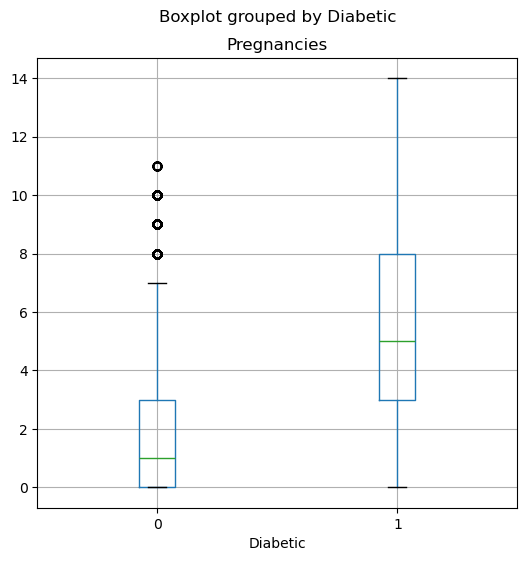

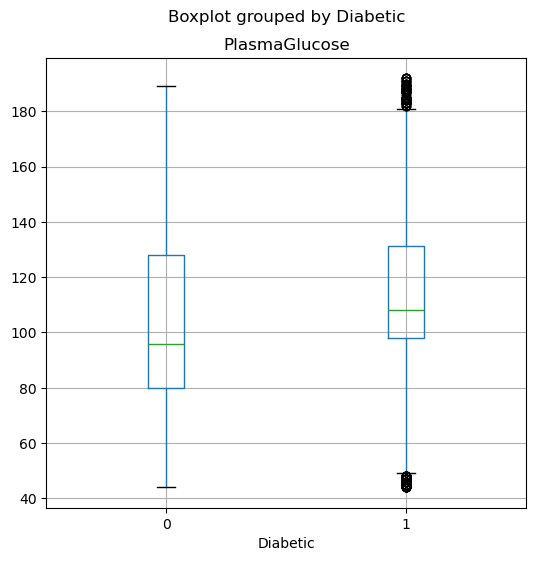

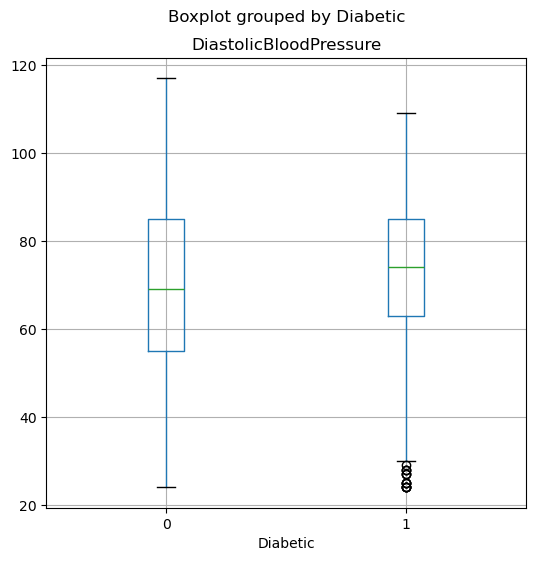

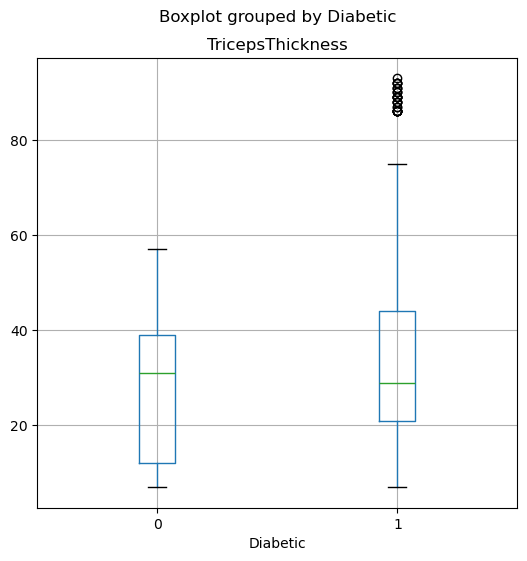

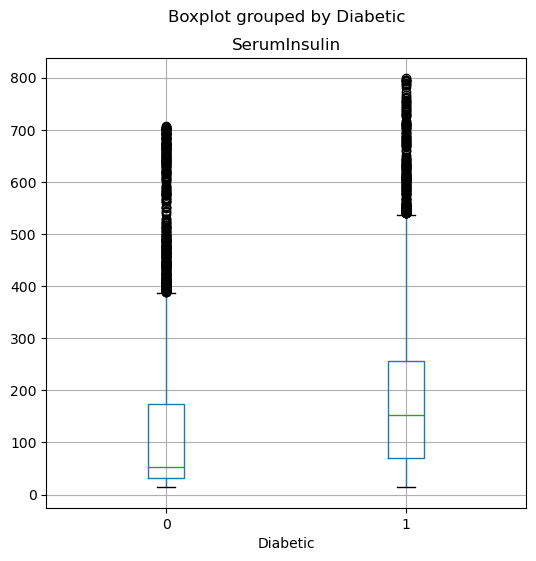

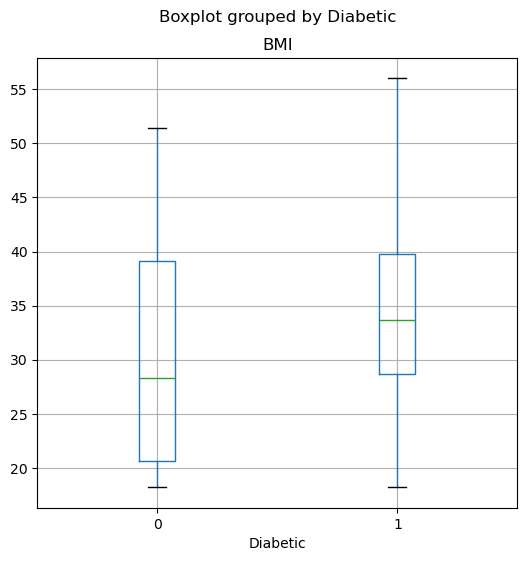

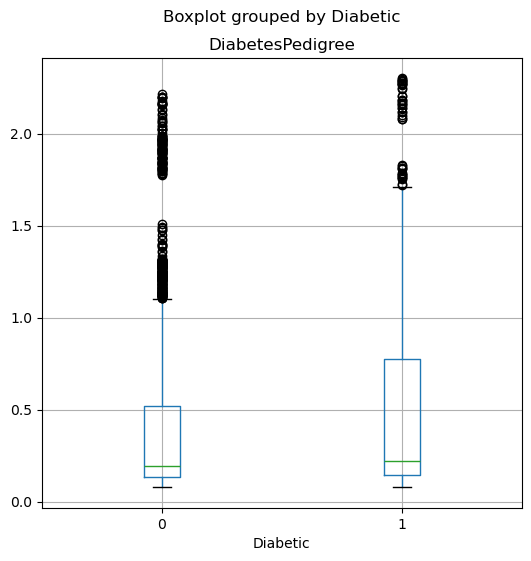

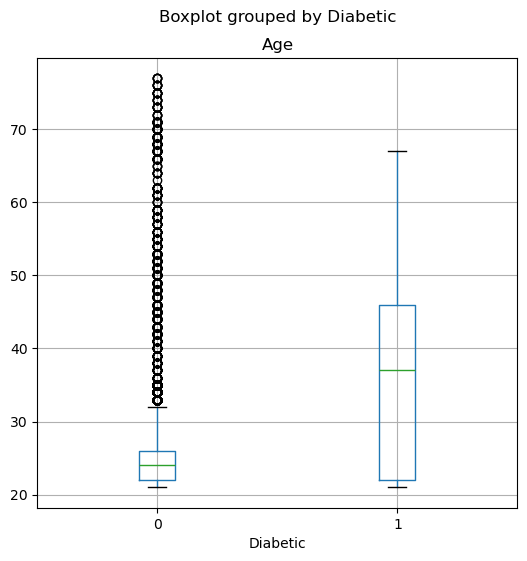

In [2]:
features = ['Pregnancies', 'PlasmaGlucose', 'DiastolicBloodPressure', 'TricepsThickness', 'SerumInsulin', 'BMI', 'DiabetesPedigree', 'Age']
label = 'Diabetic'

for col in features:
    data.boxplot(column = col, by='Diabetic', figsize = (6,6))
    plt.title(col)
plt.show()

In [3]:
X,y = data[features].values, data[label].values

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.20, random_state=0)
print ('Training cases: %d\nTest cases: %d' % (X_train.shape[0], X_test.shape[0]))

reg = 0.01
model = LogisticRegression(C = 1/reg, solver = "liblinear").fit(X_train, y_train)
print("Model = ",model)

predictions = model.predict(X_test)
print("Predicted labels : ", predictions)
print("Actual Labels : ", y_test)



Training cases: 12000
Test cases: 3000
Model =  LogisticRegression(C=100.0, solver='liblinear')
Predicted labels :  [0 0 0 ... 1 0 1]
Actual Labels :  [0 0 1 ... 1 1 1]


In [4]:
print("Accuracy Score:: ", accuracy_score(y_test, predictions))

Accuracy Score::  0.7916666666666666


In [5]:
from sklearn.metrics import classification_report
print("Classification report: \n",classification_report(y_test, predictions))

Classification report: 
               precision    recall  f1-score   support

           0       0.82      0.88      0.85      2002
           1       0.72      0.62      0.66       998

    accuracy                           0.79      3000
   macro avg       0.77      0.75      0.76      3000
weighted avg       0.79      0.79      0.79      3000



In [6]:
from sklearn.metrics import confusion_matrix
print("Confusion Matrix : \n",confusion_matrix(y_test, predictions))

Confusion Matrix : 
 [[1755  247]
 [ 378  620]]


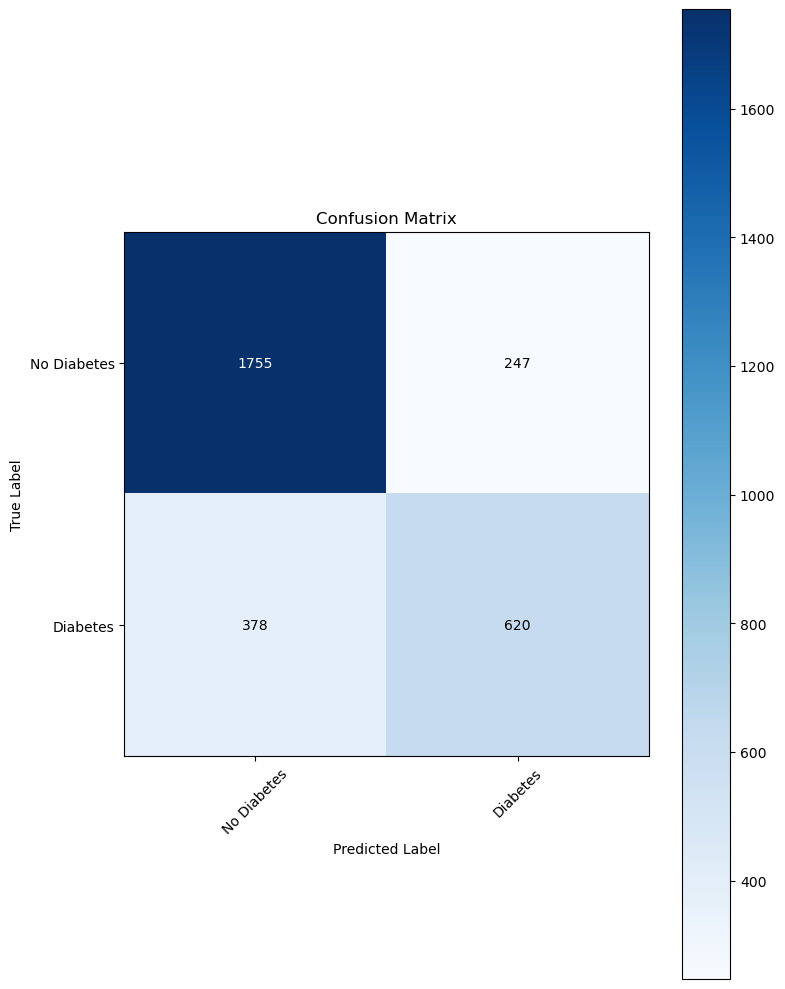

In [7]:
import numpy as np
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize = (8,10))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()

classes = ['No Diabetes', 'Diabetes']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black")

plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

Y_scores :  [[0.81230714 0.18769286]
 [0.96193193 0.03806807]
 [0.80489045 0.19510955]
 ...
 [0.01635994 0.98364006]
 [0.54848152 0.45151848]
 [0.27761499 0.72238501]]


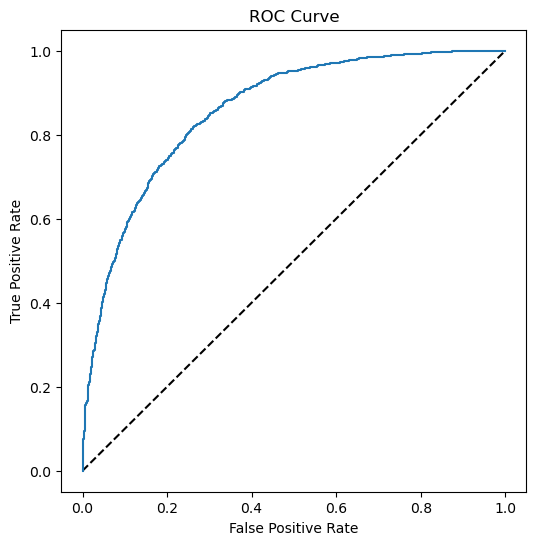

In [8]:
y_scores = model.predict_proba(X_test)
print("Y_scores : ",y_scores)
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])
#Building a roc_curve
fig = plt.figure(figsize = (6,6))
plt.plot([0,1], [0,1], 'k--')
plt.plot(fpr, tpr)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.show()


In [9]:
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(y_test, y_scores[:,1])
print("AUC : ",str(auc))

AUC :  0.8593670858199915


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_features = [0,1,2,3,4,5,6]
numeric_transformer = Pipeline(steps = [('scaler', StandardScaler())])

categorical_feature = [7]
categorical_transformer = Pipeline(steps=[('onehot',OneHotEncoder(handle_unknown = 'ignore'))])

preprocessor = ColumnTransformer(transformers = [('num', numeric_transformer, numeric_features),('cat', categorical_transformer, categorical_feature)])

pipeline = Pipeline(steps = [('preprocessor', preprocessor), ('logregressor', LogisticRegression(C=1/reg, solver='liblinear'))])

model = pipeline.fit(X_train, y_train)
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('logregressor',
                 LogisticRegression(C=100.0, solver='liblinear'))])


Confusion matrix: 
 [[1748  254]
 [ 253  745]]

Accuracy Score :  0.831

Overall Precision :  0.7457457457457457

Overall Recall :  0.7464929859719439

AUC :  0.9156770083623791


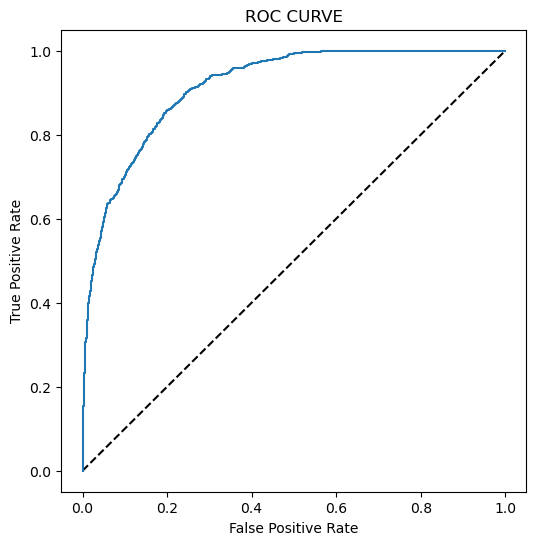

In [15]:
from sklearn.metrics import precision_score, recall_score
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

cm = confusion_matrix(y_test, predictions)
print("Confusion matrix: \n", cm)
print("\nAccuracy Score : ", accuracy_score(y_test, predictions))
print("\nOverall Precision : ", precision_score(y_test, predictions))
print("\nOverall Recall : ", recall_score(y_test, predictions))

auc = roc_auc_score(y_test, y_scores[:,1])
print("\nAUC : ",auc)

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

fig = plt.figure(figsize = (6,6))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.show()

In [16]:
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline(steps = [('preprocessor', preprocessor),('logregressor', RandomForestClassifier(n_estimators = 100))])
model = pipeline.fit(X_train, y_train)
print(model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('scaler',
                                                                   StandardScaler())]),
                                                  [0, 1, 2, 3, 4, 5, 6]),
                                                 ('cat',
                                                  Pipeline(steps=[('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  [7])])),
                ('logregressor', RandomForestClassifier())])


Confusion matrix: 
 [[1911   91]
 [ 108  890]]

Accuracy Score :  0.9336666666666666

Overall Precision :  0.9072375127420998

Overall Recall :  0.8917835671342685

AUC :  0.9830742904390198


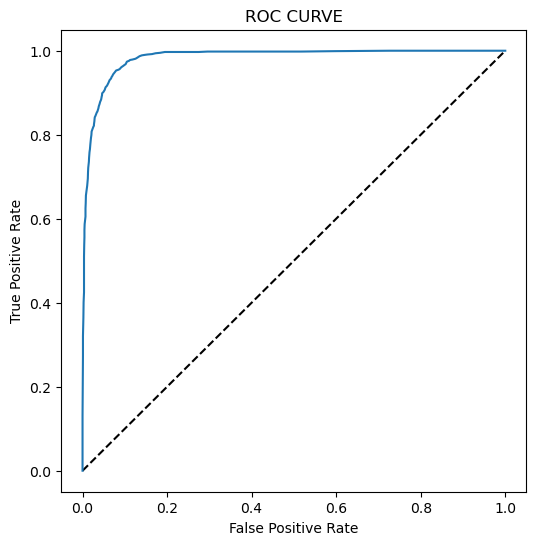

In [17]:
predictions = model.predict(X_test)
y_scores = model.predict_proba(X_test)

cm = confusion_matrix(y_test, predictions)
print("Confusion matrix: \n", cm)
print("\nAccuracy Score : ", accuracy_score(y_test, predictions))
print("\nOverall Precision : ", precision_score(y_test, predictions))
print("\nOverall Recall : ", recall_score(y_test, predictions))

auc = roc_auc_score(y_test, y_scores[:,1])
print("\nAUC : ",auc)

#ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_scores[:,1])

fig = plt.figure(figsize = (6,6))
plt.plot([0,1],[0,1],'k--')
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC CURVE")
plt.show()